# Markov Chain Monte Carlo (MCMC) Simulation and Bayesian Inference on Hair Cycle Dynamics

In [1]:
import numpy as np
import pymc as pm
import pytensor
import pytensor.tensor as at
import arviz as az
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

import jax
jax.devices()

E0329 22:53:39.667337   44739 cuda_executor.cc:1743] Could not get kernel mode driver version: ( INVALID_ARGUMENT: Version does not match the format X.Y.Z )
E0329 22:53:39.686212   44653 cuda_executor.cc:1743] Could not get kernel mode driver version: ( INVALID_ARGUMENT: Version does not match the format X.Y.Z )


[CudaDevice(id=0)]

## Step 1: Deterministic ODE model

In [2]:
#--------------------------------------------------
# Step 1: Deterministic ODE model
#--------------------------------------------------

def f_xy(x, y, lam):
    return lam * (x + y) + 1

def ode_model(t, state, params):
    xi, x, y = state

    p1 = params["p1"]; p2 = params["p2"]; p3 = params["p3"]
    Cprol = params["Cprol"]; z1 = params["z1"]; p4 = params["p4"]; p5 = params["p5"]
    k = params["k"]; alpha = params["alpha"]; beta = params["beta"]
    v = params["v"]; s = params["s"]; a = params["a"]
    l = params["l"]; b = params["b"]; w = params["w"]
    lam = params["lam"]
    
    # Equation (8)
    fxy = f_xy(x, y, lam)
    
    # Equation 9
    dxi = (
        (p1 * xi) / ((p2 + xi) * (p3 + Cprol * z1)) 
        - (fxy * p4 * xi) / (p5**k + xi**k)
        + alpha
        - beta * xi
    )

    # Equation (6)
    dx = (v * (x + y)) / ((1 + s) * (a + y + x)) + (l * x * y) / (1 + s) - x - x**2
    # Equation (7)
    dy = (b * (x + y)) / (1 + s) + (w * y) / (1 + s) - y - y**2

    return [dxi, dx, dy]

In [3]:
params = {
    "p1": 1.0, "p2": 1.0, "p3": 1.0, "Cprol": 1.0, "z1": 1.0,
    "p4": 1.0, "p5": 1.0, "k": 2,
    "alpha": 0.1, "beta": 0.05,
    "v": 1.0, "s": 0.5, "a": 1.0,
    "l": 0.2, "b": 0.3, "w": 0.4,
    "lam": 0.5,
}


t_span = (0, 50)
t_eval = np.linspace(*t_span, 501)  # Increase/decrease points to control ODE resolution and runtime
y0 = [1.0, 0.1, 0.1]


sol_ode = solve_ivp(
    fun = lambda t, y: ode_model(t, y, params),   # argument 1
    t_span = t_span,                              # argument 2
    y0 = y0,                                      # argument 3
    t_eval = t_eval                               # argument 4
)

## Step 2: Discrete‑time Markov chain approximation 

In [4]:
#----------------------------------------------------
# Step 2: Discrete‑time Markov chain approximation
#----------------------------------------------------

def clip_state(x, xmin, xmax):
    return max(xmin, min(xmax, x))

def step_markov(state, params, dt=0.1,
                xi_bounds=(0, 10), x_bounds=(0, 5), y_bounds=(0, 5),
                noise_scale=0.1):
    xi, x, y = state
    dxi, dx, dy = ode_model(0.0, state, params)  # here t = 0.0 is a dummy placeholder; the ODE is time‑independent

    # Euler step + noise → stochastic Markov transition
    xi_new = xi + dxi * dt + noise_scale * np.sqrt(dt) * np.random.randn()   # Gaussian diffusion noise (Brownian motion increment)
    x_new  = x  + dx  * dt + noise_scale * np.sqrt(dt) * np.random.randn()
    y_new  = y  + dy  * dt + noise_scale * np.sqrt(dt) * np.random.randn()

    xi_new = clip_state(xi_new, *xi_bounds)
    x_new  = clip_state(x_new,  *x_bounds)
    y_new  = clip_state(y_new,  *y_bounds)

    return np.array([xi_new, x_new, y_new])

## Step 3:  Monte Carlo simulator (many trajectories)

In [5]:
#-----------------------------------------------------
# Step 3:  Monte Carlo simulator (many trajectories)
#-----------------------------------------------------

def simulate_markov_trajectory(T=50.0, dt=0.1, y0=None, params=None):
    if y0 is None:
        y0 = np.array([1.0, 0.1, 0.1])
    n_steps = int(T / dt)
    traj = np.zeros((n_steps + 1, 3))
    traj[0] = y0
    state = y0.copy()
    for i in range(1, n_steps + 1):
        state = step_markov(state, params, dt=dt)
        traj[i] = state
    t = np.linspace(0, T, n_steps + 1)
    return t, traj

def simulate_ensemble(n_traj=100, T=50.0, dt=0.1, y0=None, params=None):
    all_traj = []
    for _ in range(n_traj):
        t, traj = simulate_markov_trajectory(T=T, dt=dt, y0=y0, params=params)
        all_traj.append(traj)
    return t, np.array(all_traj)  # shape: (n_traj, n_steps+1, 3)

t_mc, trajs_mc = simulate_ensemble(n_traj=200, T=50.0, dt=0.1, y0=y0, params=params) # change ensamble size as required

## Step 4: Bayesian model (PyMC)

In [6]:
#--------------------------------------------------
# Step 4: Bayesian model (PyMC)
#--------------------------------------------------

# --- Synthetic data from ODE solution ---
obs_times = t_eval[::20]
xi_true = sol_ode.y[0, ::20]

rng = np.random.default_rng(0)
obs_xi = xi_true + 0.1 * rng.standard_normal(size=xi_true.shape)

dt = obs_times[1] - obs_times[0]

# initial state (same as y0 used in solve_ivp)
xi0_val, x0_val, y0_val = y0

# PyTensor version of f_xy
def f_xy_at(x, y, lam):
    return lam * (x + y) + 1.0

with pm.Model() as model:

    # --------- Priors for sensitive parameters (log-scale for positivity) ---------
    log_p1    = pm.Normal("log_p1",    mu=np.log(1.0),   sigma=0.5)
    log_beta  = pm.Normal("log_beta",  mu=np.log(0.05),  sigma=0.5)
    log_z1    = pm.Normal("log_z1",    mu=np.log(1.0),   sigma=0.5)
    log_p4    = pm.Normal("log_p4",    mu=np.log(1.0),   sigma=0.5)
    log_p5    = pm.Normal("log_p5",    mu=np.log(1.0),   sigma=0.5)
    log_alpha = pm.Normal("log_alpha", mu=np.log(0.1),   sigma=0.5)

    p1    = pm.Deterministic("p1",    at.exp(log_p1))
    beta  = pm.Deterministic("beta",  at.exp(log_beta))
    z1    = pm.Deterministic("z1",    at.exp(log_z1))
    p4    = pm.Deterministic("p4",    at.exp(log_p4))
    p5    = pm.Deterministic("p5",    at.exp(log_p5))
    alpha = pm.Deterministic("alpha", at.exp(log_alpha))

    # --------- Fixed parameters from params dict ---------
    p2    = params["p2"]
    p3    = params["p3"]
    Cprol = params["Cprol"]
    k     = params["k"]
    v     = params["v"]
    s     = params["s"]
    a     = params["a"]
    l     = params["l"]
    b     = params["b"]
    w     = params["w"]
    lam   = params["lam"]

    # ------------------------------------------------------------
    # INITIAL STATE — three separate scalar streams
    # ------------------------------------------------------------
    xi0 = xi0_val
    x0  = x0_val
    y0  = y0_val

    # ------------------------------------------------------------
    # EULER STEP — return THREE SCALARS
    # ------------------------------------------------------------
    def euler_step(xi_prev, x_prev, y_prev,
               log_p1, log_beta, log_z1, log_p4, log_p5, log_alpha):

        p1    = at.exp(log_p1)
        beta  = at.exp(log_beta)
        z1    = at.exp(log_z1)
        p4    = at.exp(log_p4)
        p5    = at.exp(log_p5)
        alpha = at.exp(log_alpha)
    
        fxy = f_xy_at(x_prev, y_prev, lam)
    
        dxi = (
            (p1 * xi_prev) / ((p2 + xi_prev) * (p3 + Cprol * z1))
            - (fxy * p4 * xi_prev) / (p5**k + xi_prev**k)
            + alpha
            - beta * xi_prev
        )
    
        dx = (v * (x_prev + y_prev)) / ((1 + s) * (a + y_prev + x_prev)) \
             + (l * x_prev * y_prev) / (1 + s) - x_prev - x_prev**2
    
        dy = (b * (x_prev + y_prev)) / (1 + s) \
             + (w * y_prev) / (1 + s) - y_prev - y_prev**2
    
        # ensure same dtype as the previous state
        xi_new = at.cast(xi_prev + dxi * dt, xi_prev.dtype)
        x_new  = at.cast(x_prev  + dx  * dt, x_prev.dtype)
        y_new  = at.cast(y_prev  + dy  * dt, y_prev.dtype)
    
        return xi_new, x_new, y_new


    # ------------------------------------------------------------
    # SCAN — three separate output streams
    # ------------------------------------------------------------

    xi_seq, x_seq, y_seq = pytensor.scan(
        fn=euler_step,
        outputs_info=[xi0, x0, y0],
        non_sequences=[log_p1, log_beta, log_z1, log_p4, log_p5, log_alpha],
        n_steps=len(obs_times) - 1,
        return_updates=False,
    )


    # ------------------------------------------------------------
    # BUILD PREDICTED TRAJECTORIES
    # ------------------------------------------------------------
    xi_pred = at.concatenate([at.stack([xi0]), xi_seq])

    sigma = pm.HalfNormal("sigma", sigma=0.1)

    pm.Normal("obs", mu=xi_pred, sigma=sigma, observed=obs_xi)

    trace = pm.sample(
        draws=2000,
        tune=1000,
        target_accept=0.98,
        chains=4,
        # cores=1,
        nuts_sampler="numpyro",
        nuts_sampler_kwargs={"chain_method": "vectorized"},
        random_seed=0,
    )

# print(trace.sample_stats.diverging.sum().values)

real_vars = ["p1", "beta", "z1", "p4", "p5", "alpha", "sigma"]
log_vars  = ["log_p1", "log_beta", "log_z1",
             "log_p4", "log_p5", "log_alpha"]


summary = az.summary(trace, var_names=real_vars)
log_summary = az.summary(trace, var_names=log_vars)
summary

sample: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [43:37<00:00,  1.15it/s]
There were 456 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p1,0.690,0.435,0.102,1.314,0.171,0.057,7.0,34.0,1.53
beta,0.068,0.036,0.025,0.116,0.015,0.005,9.0,133.0,1.37
z1,2.716,2.223,0.579,6.740,1.087,0.594,6.0,12.0,2.87
p4,2.351,1.951,0.617,5.676,0.968,0.529,5.0,20.0,2.77
p5,1.207,0.623,0.430,2.097,0.296,0.127,5.0,4.0,2.56
alpha,0.052,0.028,0.022,0.102,0.010,0.003,6.0,26.0,1.82
sigma,0.261,0.291,0.076,0.768,0.145,0.084,7.0,11.0,2.86


## Step 5: MCMC Convergence Diagnostics

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
p1     0.690  0.435   0.102    1.314      0.171    0.057       7.0      34.0   
beta   0.068  0.036   0.025    0.116      0.015    0.005       9.0     133.0   
z1     2.716  2.223   0.579    6.740      1.087    0.594       6.0      12.0   
p4     2.351  1.951   0.617    5.676      0.968    0.529       5.0      20.0   
p5     1.207  0.623   0.430    2.097      0.296    0.127       5.0       4.0   
alpha  0.052  0.028   0.022    0.102      0.010    0.003       6.0      26.0   
sigma  0.261  0.291   0.076    0.768      0.145    0.084       7.0      11.0   

       r_hat  
p1      1.53  
beta    1.37  
z1      2.87  
p4      2.77  
p5      2.56  
alpha   1.82  
sigma   2.86  
            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
log_p1    -0.703  0.953  -2.282    0.273      0.452    0.232       7.0   
log_beta  -2.830  0.532  -3.697   -2.152      0.204    0.054       9.0   
log_z1     0.679 

/home/paudel/y/envs/mathe116_pymcjax311/lib/python3.11/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/home/paudel/y/envs/mathe116_pymcjax311/lib/python3.11/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/home/paudel/y/envs/mathe116_pymcjax311/lib/python3.11/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/home/paudel/y/envs/mathe116_pymcjax311/lib/python3.11/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single 

<Figure size 1200x1000 with 0 Axes>

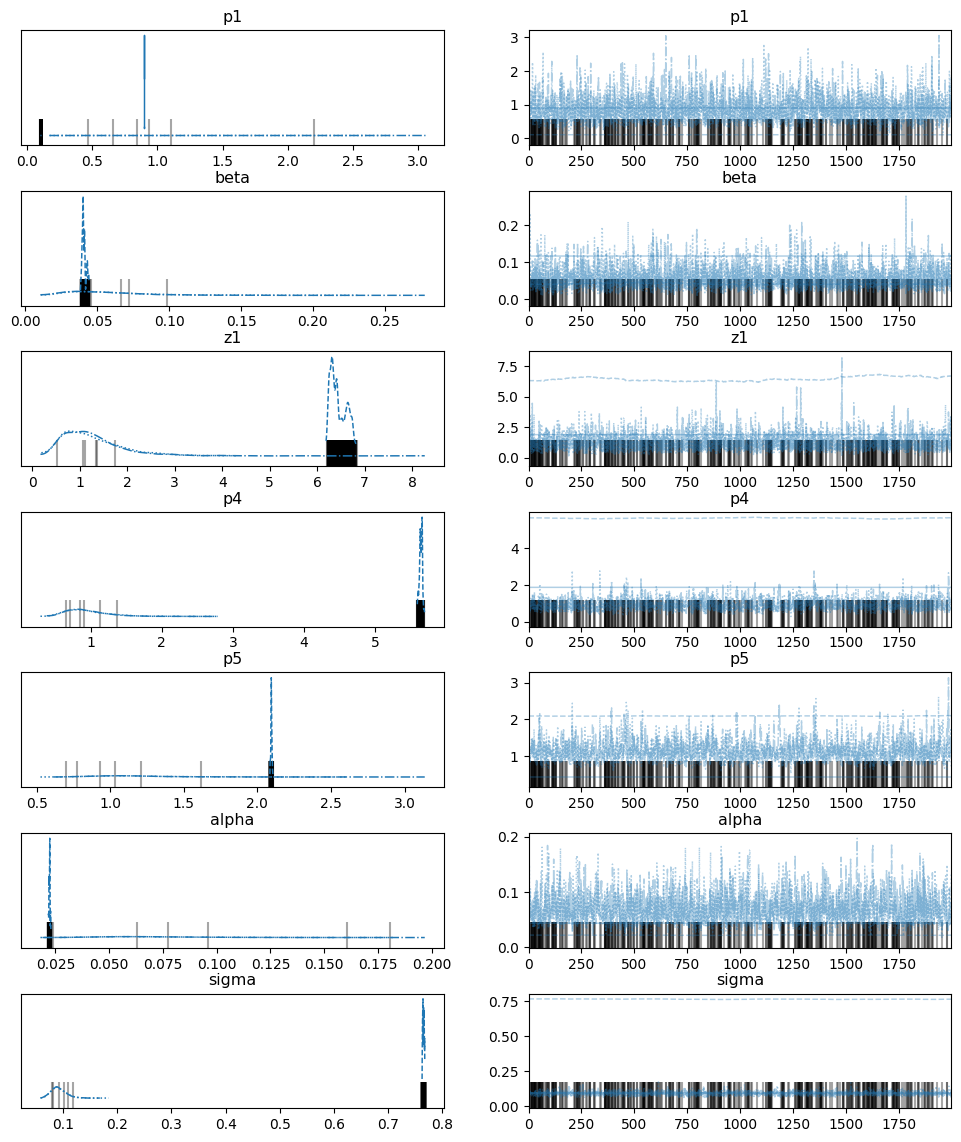

<Figure size 1200x1000 with 0 Axes>

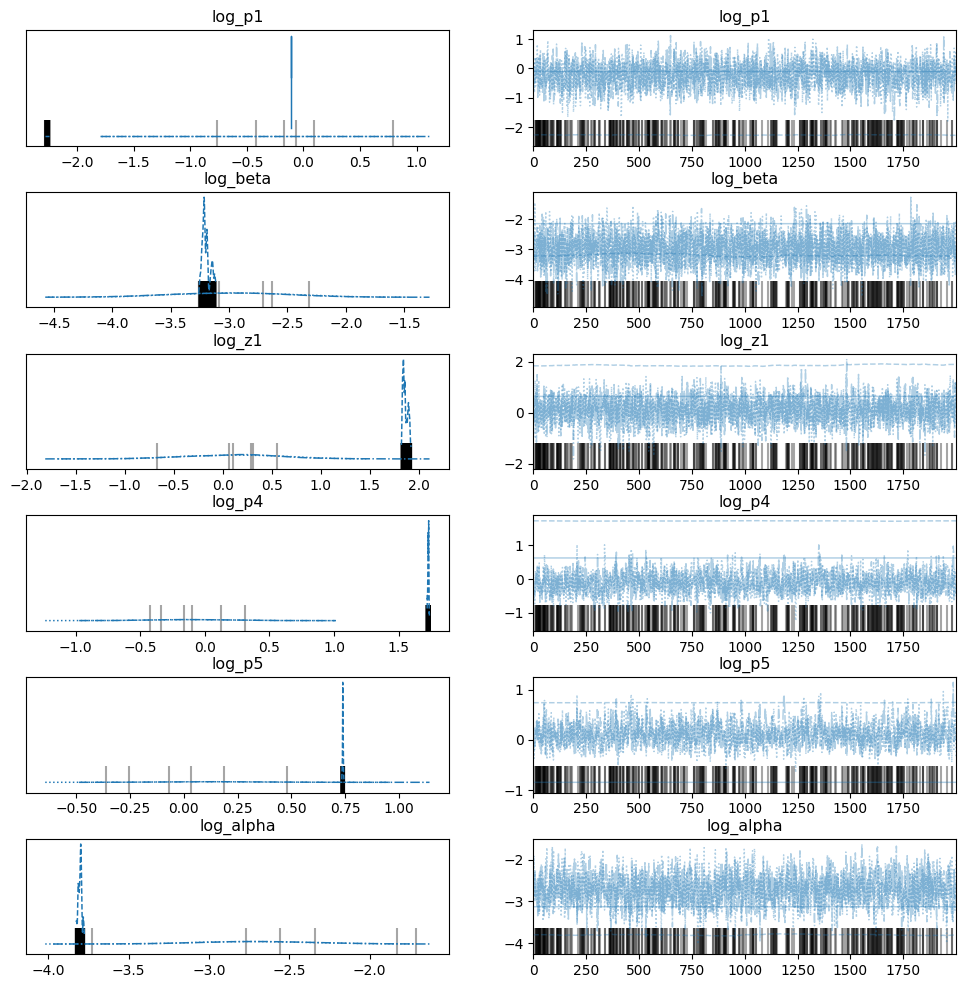

In [7]:
#---------------------------------------------
# Step 5: MCMC Convergence Diagnostics  
#---------------------------------------------

print(summary)
print(log_summary)

# Real-scale parameters
plt.figure(figsize=(12, 10))
az.plot_trace(trace, var_names=real_vars)
plt.subplots_adjust(hspace=0.4)

# Log-scale parameters
plt.figure(figsize=(12, 10))
az.plot_trace(trace, var_names=log_vars)
plt.subplots_adjust(hspace=0.4)

## Step 6: Posterior Predictive Check on Simulated Data

Sampling: [obs]


Output()

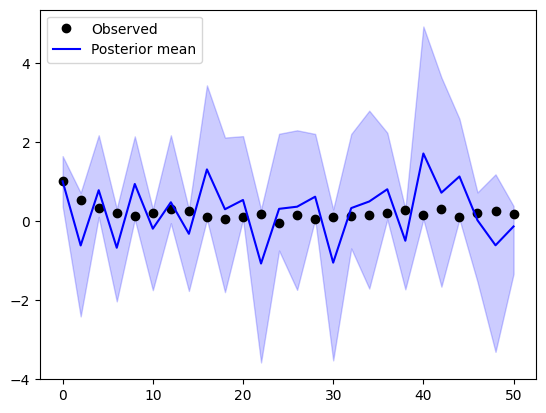

In [8]:
#-------------------------------------------------------
# Step 6: Posterior Predictive Check on Simulated Data
#-------------------------------------------------------

#--- Posterior predictive (runs on GPU if available, otherwise CPU) ---
with model:
    ppc = pm.sample_posterior_predictive(trace)

y_ppc = ppc.posterior_predictive["obs"].values

plt.plot(obs_times, obs_xi, "ko", label="Observed")
plt.plot(obs_times, y_ppc.mean(axis=(0, 1)), "b-", label="Posterior mean")
plt.fill_between(
    obs_times,
    np.percentile(y_ppc, 5, axis=(0, 1)),
    np.percentile(y_ppc, 95, axis=(0, 1)),
    color="blue",
    alpha=0.2,
)
plt.legend()
plt.show()

## Step 7: Deterministic vs Stochastic Comparison

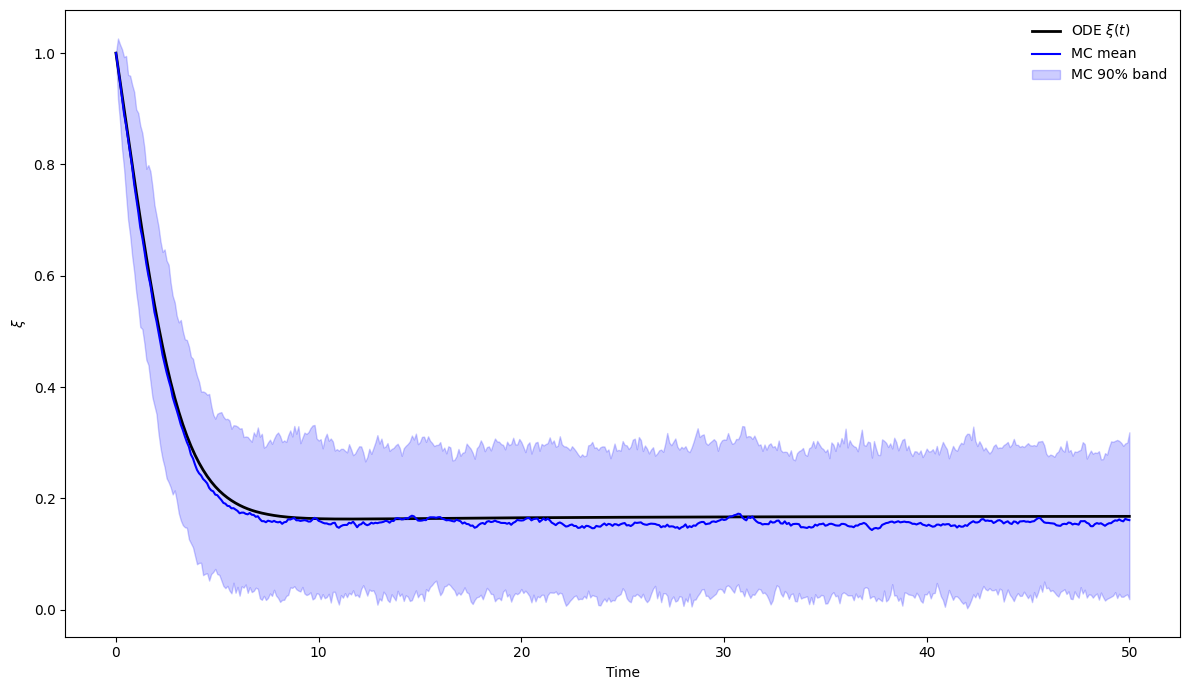

In [9]:
#--------------------------------------------------
# Step 7: Deterministic vs Stochastic Comparison
#--------------------------------------------------

plt.figure(figsize=(12, 7))

# --- Deterministic ODE reference ---
plt.plot(
    sol_ode.t,
    sol_ode.y[0],
    color="black",
    linewidth=2,
    label=r"ODE $\xi(t)$"
)

# --- Monte Carlo ensemble statistics ---
xi_mc = trajs_mc[:, :, 0]  # shape: (n_traj, n_steps+1)
xi_mc_mean = xi_mc.mean(axis=0)
xi_mc_low  = np.percentile(xi_mc, 5, axis=0)
xi_mc_high = np.percentile(xi_mc, 95, axis=0)

plt.plot(t_mc, xi_mc_mean, color="blue", label="MC mean")
plt.fill_between(
    t_mc,
    xi_mc_low,
    xi_mc_high,
    color="blue",
    alpha=0.2,
    label="MC 90% band"
)

plt.xlabel("Time")
plt.ylabel(r"$\xi$")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

## Stochastic Oscillatory Dynamics of Human Hair Follicles
Based on a paper: Halloy et al., PNAS, 2000, 97, 8328±8333

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

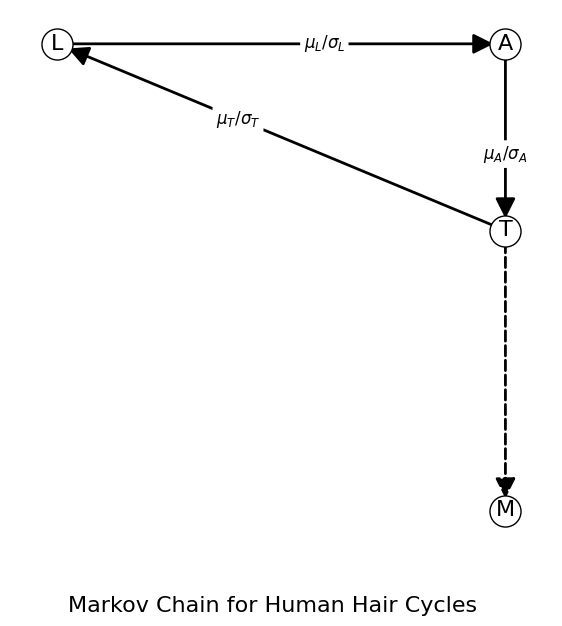

In [11]:

G = nx.DiGraph()

# Nodes
G.add_nodes_from(["L", "A", "T", "M"])

# Edge labels
edge_labels = {
    ("L", "A"): r"$\mu_L / \sigma_L$",
    ("T", "L"): r"$\mu_T / \sigma_T$",
    ("A", "T"): r"$\mu_A / \sigma_A$",
    ("T", "M"): r""
}

# Add edges
for e in edge_labels:
    G.add_edge(*e)

# Layout matching your diagram
pos = {
    "L": (0, 0.5),
    "A": (1.2, 0.5),
    "T": (1.2, 0.1),
    "M": (1.2, -0.5)
}

plt.figure(figsize=(7, 7))

# Draw nodes
nx.draw_networkx_nodes(
    G, pos,
    node_size=500,
    node_color="white",
    edgecolors="black"
)

# SOLID directed edges
solid_edges = [("L", "A"), ("T", "L"), ("A", "T")]
nx.draw_networkx_edges(
    G, pos,
    edgelist=solid_edges,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=30,
    width=2
)

# DASHED directed edge
nx.draw_networkx_edges(
    G, pos,
    edgelist=[("T", "M")],
    arrows=True,
    arrowstyle="-|>",
    arrowsize=30,
    style="dashed",
    width=2
)

# Node labels
nx.draw_networkx_labels(G, pos, font_size=16)

# Edge labels (no custom positions)
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edge_labels,
    font_size=12,
    label_pos=0.6,        # move slightly along the edge
    rotate=False,
    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none")
)

plt.axis("off")

# Bottom title
plt.figtext(0.5, 0.02, "Markov Chain for Human Hair Cycles",
            ha="center", fontsize=16)

plt.show()

The distribution of the durations of each follicular phase is represented by a log-normal function:

$$
f(x;\,\mu,\sigma)
= \frac{1}{x\,\sigma\sqrt{2\pi}}
\exp\!\left(
-\frac{(\log x - \mu)^2}{2\sigma^2}
\right),
\qquad x>0 \tag{1}
$$

In [12]:
#---------------------------------------------------------
# 1. Log-normal duration sampler
#    (Phase durations drawn from empirical distributions)
#---------------------------------------------------------
def sample_duration(mu, sigma):
    """Sample a phase duration from the log-normal distribution in Eq. (1)."""
    return np.random.lognormal(mean=mu, sigma=sigma)


#---------------------------------------------------------
# 2. Probability of transition into pathological state M
#    (Slowly increasing probability as cycles accumulate)
#---------------------------------------------------------
def p_to_M(cycles):
    """Slowly increasing probability of transitioning to M."""
    return min(0.01 * (1 + 0.1 * cycles), 0.2)

# def p_to_M_time(t, T_end):
#     base = 0.002
#     ramp = 0.01 * (t / T_end)
#     return min(base + ramp, 0.2)


#---------------------------------------------------------
# 3. Baseline follicle-cycle structure (A → T → L → A)
#---------------------------------------------------------
next_phase = {
    "A": "T",
    "T": "L",
    "L": "A"
}


#-----------------------------------------------------------
# 5. Phase-duration parameters for A, T, L, and optional M
#-----------------------------------------------------------
def convert_to_lognormal_params(mean, variance):
    sigma2_log = np.log(1 + variance / (mean**2))
    sigma_log = np.sqrt(sigma2_log)
    mu_log = np.log(mean) - 0.5 * sigma2_log
    return mu_log, sigma_log

# phase_params = {
#     "A": convert_to_lognormal_params(6.49, 10.16),
#     "T": convert_to_lognormal_params(2.17, 1.11),
#     "L": convert_to_lognormal_params(4.56, 9.57)
# }

mu_M = 3.0      # example mean duration of M
var_M = 2.0     # example variance of M

phase_params = {
    "A": convert_to_lognormal_params(6.49, 10.16),
    "T": convert_to_lognormal_params(2.17, 1.11),
    "L": convert_to_lognormal_params(4.56, 9.57),
    "M": convert_to_lognormal_params(mu_M, var_M)   # you choose these
}



# phase_params = {
#     "A": convert_to_lognormal_params(16.91, 19.49**2),
#     "T": convert_to_lognormal_params(1.79, 0.82**2),
#     "L": convert_to_lognormal_params(5.23, 5.18**2)
# }


#---------------------------------------------------------
# 6. Phase-transition rule
#    (Normal cycling or optional transition into M)
#---------------------------------------------------------
def choose_next_phase(phase, cycles, include_M=True):
    """
    Determine the next phase in the follicle cycle.
    If include_M=True, allow a slow-probability transition to M.
    """
    # If follicle is already in M, it stays there
    if phase == "M":
        return "M"

    # Normal cycle transitions
    next_phase_map = {"A": "T", "T": "L", "L": "A"}

    # If M transitions are disabled
    if not include_M:
        return next_phase_map[phase]

    # Otherwise include slow probability to M
    pM = p_to_M(cycles)
    # pM = p_to_M_time(t, T_end)

    if np.random.rand() < pM:
        return "M"
    else:
        return next_phase_map[phase]


#---------------------------------------------------------
# 7. Simulate a single follicle over T_end months
#---------------------------------------------------------
def simulate_follicle(T_end, initial_phase="A", include_M=True):
    phase = initial_phase
    cycles = 0
    time_to_transition = sample_duration(*phase_params[phase])

    phases = []
    cycle_counts = []

    for t in range(T_end):

        # If already in M, stay in M
        if phase == "M":
            phases.append("M")
            cycle_counts.append(cycles)
            continue

        phases.append(phase)
        cycle_counts.append(cycles)

        time_to_transition -= 1

        if time_to_transition <= 0:

            # Use the new choice function
            phase = choose_next_phase(phase, cycles, include_M=include_M)

            # If moved to M, no new duration needed
            if phase == "M":
                continue

            # Otherwise sample new duration
            time_to_transition = sample_duration(*phase_params[phase])

            # Count cycles when entering A
            if phase == "A":
                cycles += 1

    return phases, cycle_counts


#---------------------------------------------------------
# 8. Simulate a population of independent follicles
#---------------------------------------------------------
def simulate_population(N_follicles, T_end, include_M=True):
    all_phases = []
    all_cycles = []

    for i in range(N_follicles):
        phases, cycles = simulate_follicle(T_end, include_M=include_M)
        all_phases.append(phases)
        all_cycles.append(cycles)

    return np.array(all_phases), np.array(all_cycles)


#---------------------------------------------------------
# 9. Population-level statistics at a given time t
#---------------------------------------------------------
def population_statistics(all_phases, all_cycles, t):
    """
    Compute number of follicles in each phase at time t,
    and mean number of cycles performed.
    """
    phases_t = all_phases[:, t]
    cycles_t = all_cycles[:, t]

    return {
        "A": np.sum(phases_t == "A"),
        "T": np.sum(phases_t == "T"),
        "L": np.sum(phases_t == "L"),
        "M": np.sum(phases_t == "M"),
        "mean_cycles": np.mean(cycles_t)
    }



#---------------------------------------------------------
# 10. Paired simulations: with-M vs without-M transitions
#---------------------------------------------------------
def run_two_simulations(N, T_end):
    # With M transitions
    phases_M, cycles_M = simulate_population(N, T_end, include_M=True)

    # Without M transitions
    phases_noM, cycles_noM = simulate_population(N, T_end, include_M=False)

    return (phases_M, cycles_M), (phases_noM, cycles_noM)



#---------------------------------------------------------
# 11. Single demonstration run (quick inspection)
#---------------------------------------------------------
N = 1000       # follicles
T_end = 200    # months

all_phases, all_cycles = simulate_population(N, T_end)

stats_50 = population_statistics(all_phases, all_cycles, t=50)
print(stats_50)


#---------------------------------------------------------
# 12. Run paired simulations for comparative analysis
#---------------------------------------------------------
(sim_M, cyc_M), (sim_noM, cyc_noM) = run_two_simulations(1000, 200)

{'A': np.int64(411), 'T': np.int64(180), 'L': np.int64(292), 'M': np.int64(117), 'mean_cycles': np.float64(2.744)}


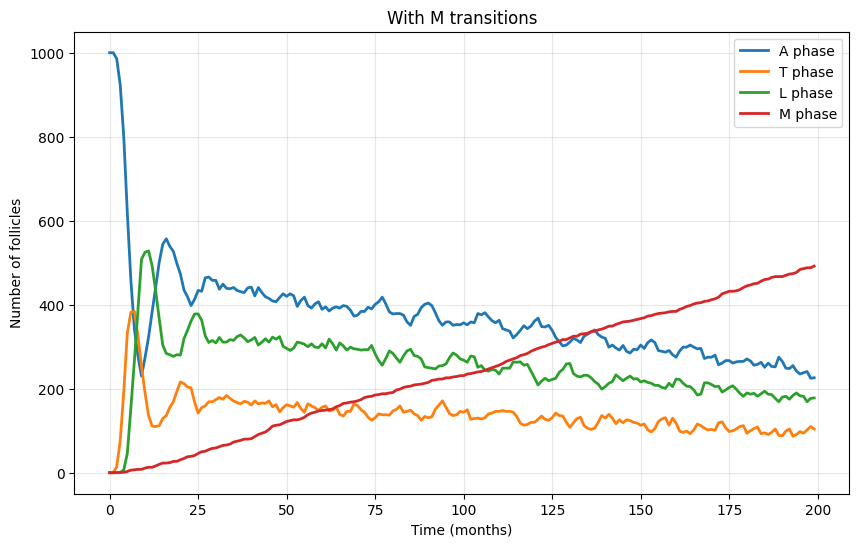

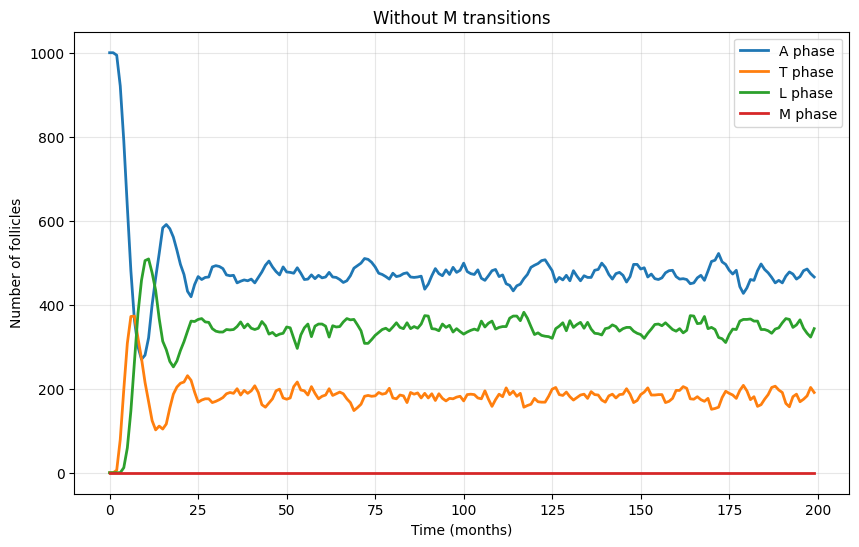

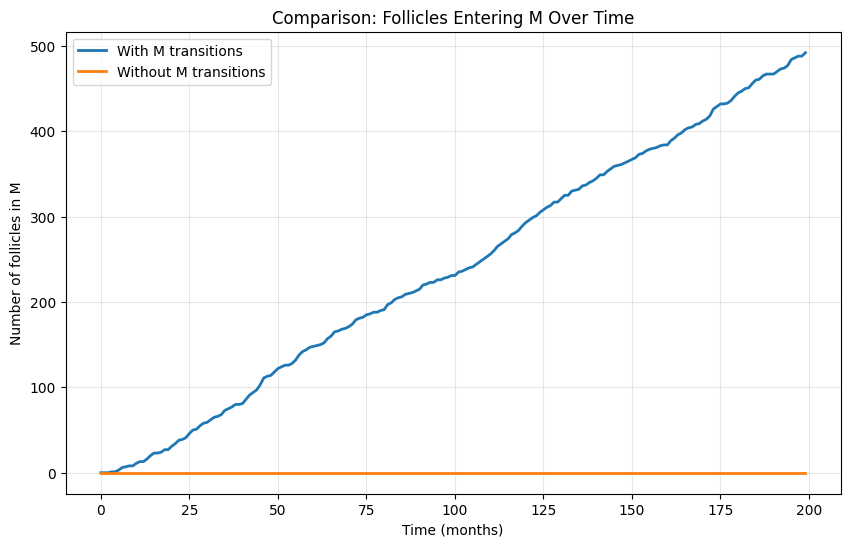

In [13]:

# ---------------------------------------------------------
# Plot phase counts for a single simulation
# ---------------------------------------------------------
def plot_phase_counts(all_phases, title="Phase Counts Over Time"):
    T_end = all_phases.shape[1]
    times = np.arange(T_end)

    counts_A = np.sum(all_phases == "A", axis=0)
    counts_T = np.sum(all_phases == "T", axis=0)
    counts_L = np.sum(all_phases == "L", axis=0)
    counts_M = np.sum(all_phases == "M", axis=0)

    plt.figure(figsize=(10, 6))

    plt.plot(times, counts_A, label="A phase", linewidth=2)
    plt.plot(times, counts_T, label="T phase", linewidth=2)
    plt.plot(times, counts_L, label="L phase", linewidth=2)
    plt.plot(times, counts_M, label="M phase", linewidth=2)

    plt.xlabel("Time (months)")
    plt.ylabel("Number of follicles")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


# ---------------------------------------------------------
# Plot both scenarios separately
# ---------------------------------------------------------
plot_phase_counts(sim_M, title="With M transitions")
plot_phase_counts(sim_noM, title="Without M transitions")


# ---------------------------------------------------------
# Comparison plot: M vs no-M
# ---------------------------------------------------------
def compare_M_vs_noM(phases_M, phases_noM):
    T_end = phases_M.shape[1]
    times = np.arange(T_end)

    M_with = np.sum(phases_M == "M", axis=0)
    M_without = np.sum(phases_noM == "M", axis=0)  # always zero

    plt.figure(figsize=(10, 6))

    plt.plot(times, M_with, label="With M transitions", linewidth=2)
    plt.plot(times, M_without, label="Without M transitions", linewidth=2)

    plt.xlabel("Time (months)")
    plt.ylabel("Number of follicles in M")
    plt.title("Comparison: Follicles Entering M Over Time")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


compare_M_vs_noM(sim_M, sim_noM)

In [14]:

def plot_single_follicle(phases, title="Follicle trajectory"):
    """
    Plot a single follicle's phase transitions over time
    in the same style as the experimental/model figure.
    """

    # Map phases to numeric levels
    mapping = {"T": 2, "A": 1, "L": 0, "M": -1}

    # Convert phases to numeric values
    try:
        numeric = np.array([mapping[p] for p in phases])
    except KeyError as e:
        print("ERROR: Unknown phase found:", e)
        print("Unique phases in data:", set(phases))
        return

    times = np.arange(len(phases))

    plt.figure(figsize=(10, 4))

    # Step plot (matches the figure style)
    plt.step(times, numeric, where="post", linewidth=2)

    # Y‑axis ticks and labels
    plt.yticks(
        [2, 1, 0, -1],
        ["T", "A", "L", "M"]
    )

    plt.xlabel("Time (months)")
    plt.ylabel("Phase")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.ylim(-1.5, 2.5)

    plt.show()

In [15]:

print(sim_M[0][:50])

['A' 'A' 'A' 'A' 'A' 'A' 'A' 'T' 'T' 'L' 'L' 'A' 'A' 'A' 'A' 'T' 'T' 'L'
 'L' 'L' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'T' 'T' 'L' 'L' 'A' 'A' 'A'
 'A' 'A' 'A' 'A' 'A' 'T' 'T' 'T' 'L' 'L' 'L' 'L' 'L' 'L']


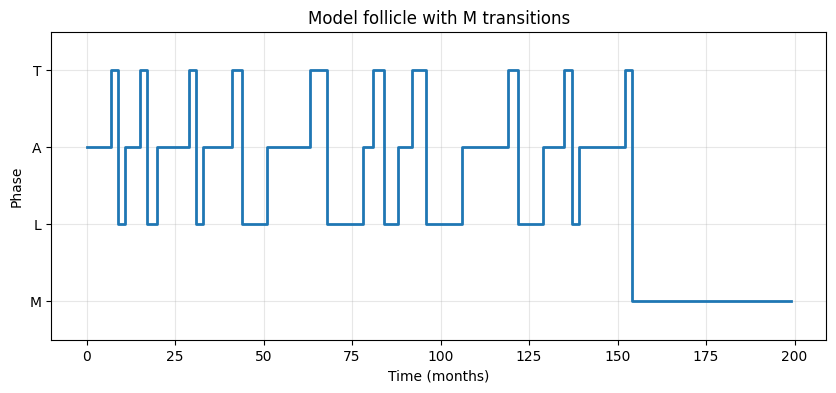

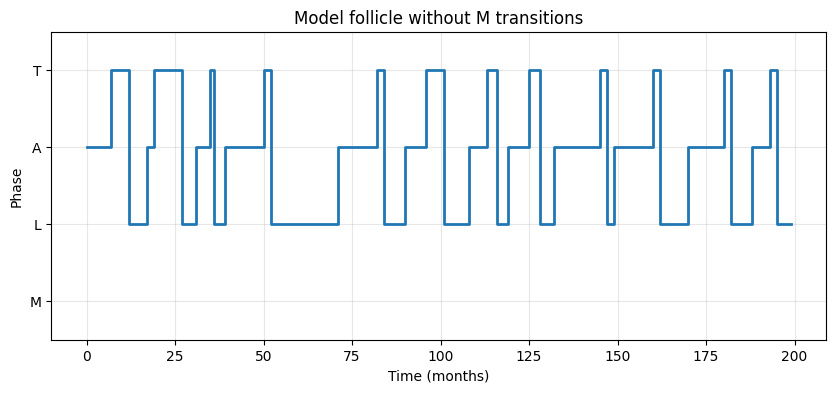

In [16]:
follicle_index = 0  # choose any follicle
phases = sim_M[follicle_index]

plot_single_follicle(phases, title="Model follicle with M transitions")

phases_noM = sim_noM[follicle_index]

plot_single_follicle(phases_noM, title="Model follicle without M transitions")

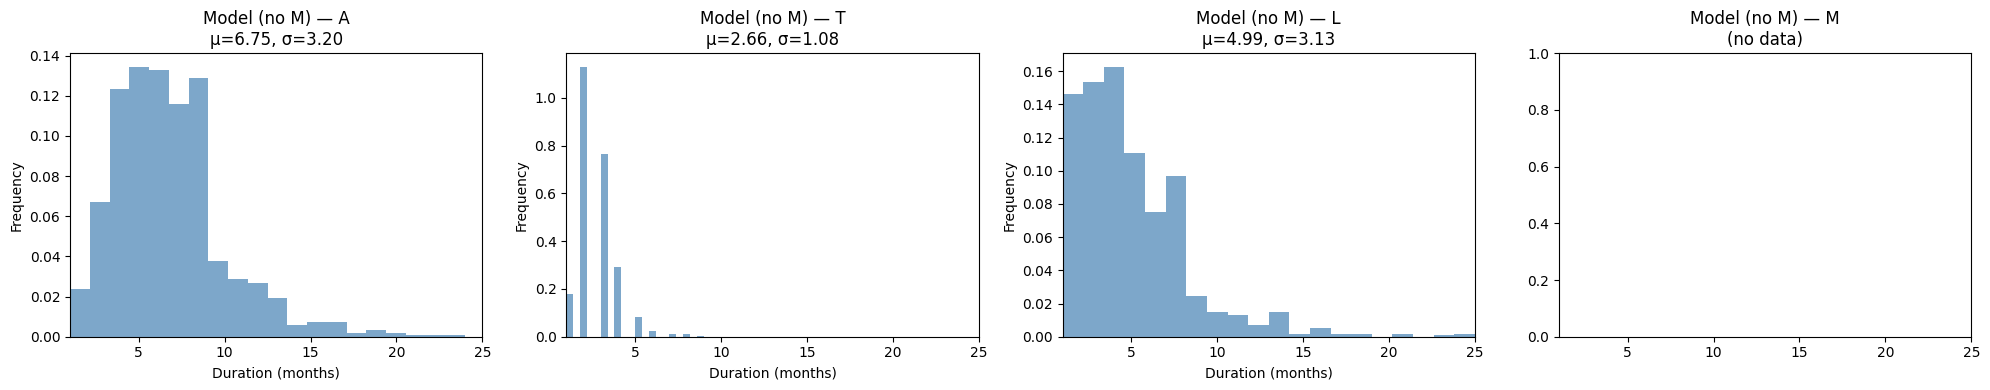

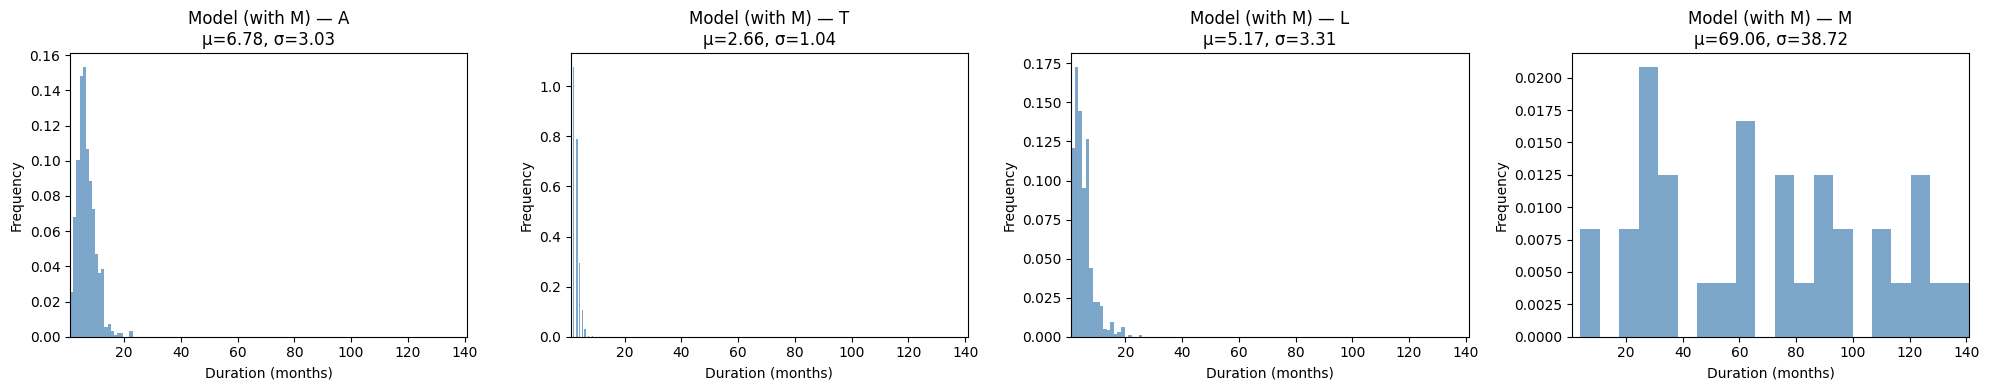

In [17]:

def extract_phase_durations_all(phases):
    durations = {"A": [], "T": [], "L": [], "M": []}
    current = phases[0]
    count = 1

    for p in phases[1:]:
        if p == current:
            count += 1
        else:
            durations[current].append(count)
            current = p
            count = 1

    durations[current].append(count)
    return durations


def plot_duration_histograms_all(all_durations, xmin, xmax, title_prefix="Model"):
    phases = ["A", "T", "L", "M"]
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

    for ax, phase in zip(axes, phases):
        data = np.array(all_durations[phase])

        if len(data) == 0:
            ax.set_title(f"{title_prefix} — {phase}\n(no data)")
            ax.set_xlim(xmin, xmax)
            continue

        mu = np.mean(data)
        sigma = np.std(data)

        ax.hist(data, bins=20, density=True, alpha=0.7, color="steelblue")
        ax.set_title(f"{title_prefix} — {phase}\nμ={mu:.2f}, σ={sigma:.2f}")
        ax.set_xlabel("Duration (months)")
        ax.set_ylabel("Frequency")
        ax.set_xlim(xmin, xmax)

    plt.tight_layout()
    plt.show()



# ---------------------------------------------------------
# Extracting required information and Run plotting
# ---------------------------------------------------------

(sim_M, cyc_M), (sim_noM, cyc_noM) = run_two_simulations(100, 144)


# Extract durations for WITH-M simulation
all_noM = {"A": [], "T": [], "L": [], "M": []}
for follicle in sim_noM:
    d = extract_phase_durations_all(follicle)
    for phase in all_noM:
        all_noM[phase].extend(d[phase])


# Compute x-limits
all_values_noM = []
for phase in all_noM:
    all_values_noM.extend(all_noM[phase])
xmin_noM = min(all_values_noM)
xmax_noM = max(all_values_noM)


# Extract durations for WITH-M simulation
all_M = {"A": [], "T": [], "L": [], "M": []}
for follicle in sim_M:
    d = extract_phase_durations_all(follicle)
    for phase in all_M:
        all_M[phase].extend(d[phase])


# Compute x-limits
all_values_M = []
for phase in all_M:
    all_values_M.extend(all_M[phase])
xmin_M = min(all_values_M)
xmax_M = max(all_values_M)


# Plot
plot_duration_histograms_all(all_noM, xmin_noM, xmax_noM, title_prefix="Model (no M)")
plot_duration_histograms_all(all_M, xmin_M, xmax_M, title_prefix="Model (with M)")